# LIBOR Market Model (LMM) Tutorial

This tutorial demonstrates how to use the LIBOR Market Model in QuantStrata for:

1. Setting up the model with forward curves and correlation
2. Monte Carlo simulation of forward rates
3. Pricing caplets and floorlets
4. Pricing European swaptions
5. Analyzing correlation effects

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.models.forward_rate import (
    LMMCorrelation,
    LMMParameters,
    LMMDynamics,
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# For reproducibility
np.random.seed(42)

## 1. Model Setup

The LMM requires:
- **Tenor structure**: Forward rate fixing dates
- **Initial forward curve**: Today's forward rates
- **Volatilities**: Instantaneous volatilities for each forward
- **Correlation**: How forward rates move together

In [2]:
# Setup: 5-year quarterly forward curve (20 forwards)
n_forwards = 20
tenor_spacing = 0.25  # Quarterly

# Tenor dates: T_0, T_1, ..., T_n
tenors = np.linspace(0.0, n_forwards * tenor_spacing, n_forwards + 1)

# Accrual factors (approximately equal to tenor spacing)
accrual_factors = np.full(n_forwards, tenor_spacing)

print(f"Tenors: {tenors[:5]}... (20 periods)")
print(f"Terminal time: {tenors[-1]:.1f} years")

Tenors: [0.   0.25 0.5  0.75 1.  ]... (20 periods)
Terminal time: 5.0 years


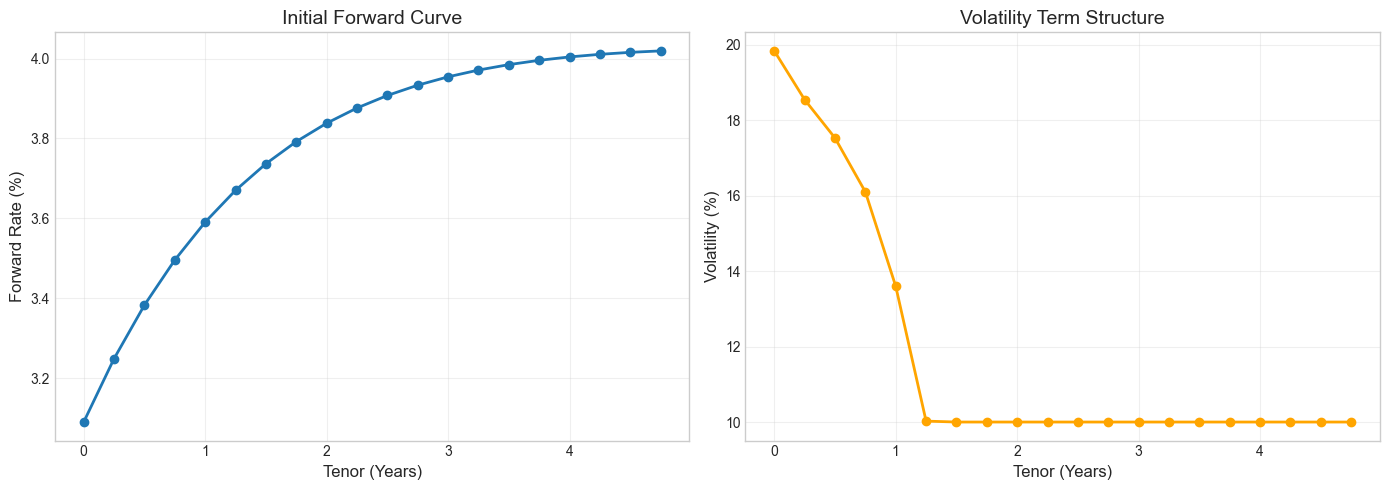

Initial forward range: 3.09% - 4.02%
Volatility range: 10.0% - 19.8%


In [3]:
# Initial forward curve (realistic upward sloping)
# Using Nelson-Siegel-like parameterization
def forward_curve(T, level=0.03, slope=0.01, curvature=0.005, tau=2.0):
    """Generate forward rates using Nelson-Siegel style."""
    return level + slope * (1 - np.exp(-T/tau)) + curvature * (T/tau) * np.exp(-T/tau)

initial_forwards = forward_curve(tenors[:-1] + tenor_spacing/2)

# Volatility term structure (humped shape)
def vol_curve(T, base=0.20, hump_height=0.05, hump_loc=1.0, decay=0.1):
    """Generate volatility term structure with hump."""
    return base + hump_height * np.exp(-0.5 * ((T - hump_loc) / 0.5)**2) - decay * T

volatilities = vol_curve(tenors[:-1] + tenor_spacing/2)
volatilities = np.maximum(volatilities, 0.10)  # Floor at 10%

# Plot the curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tenors[:-1], initial_forwards * 100, 'o-', linewidth=2, markersize=6)
axes[0].set_xlabel('Tenor (Years)', fontsize=12)
axes[0].set_ylabel('Forward Rate (%)', fontsize=12)
axes[0].set_title('Initial Forward Curve', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(tenors[:-1], volatilities * 100, 'o-', linewidth=2, markersize=6, color='orange')
axes[1].set_xlabel('Tenor (Years)', fontsize=12)
axes[1].set_ylabel('Volatility (%)', fontsize=12)
axes[1].set_title('Volatility Term Structure', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial forward range: {initial_forwards.min()*100:.2f}% - {initial_forwards.max()*100:.2f}%")
print(f"Volatility range: {volatilities.min()*100:.1f}% - {volatilities.max()*100:.1f}%")

### 1.1 Correlation Structure

Forward rates are correlated - nearby forwards move more together than distant ones.

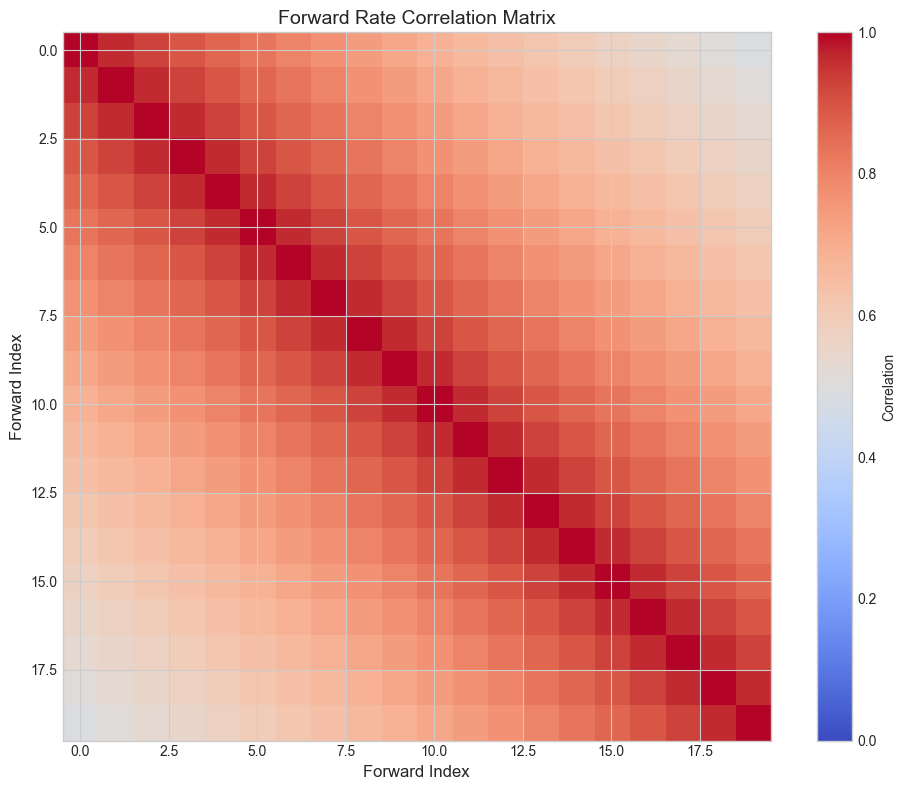

Correlation F_0 vs F_1: 0.963
Correlation F_0 vs F_10: 0.687
Correlation F_0 vs F_19: 0.490


In [4]:
# Exponential correlation: ρ_ij = exp(-β|T_i - T_j|)
correlation = LMMCorrelation(
    n_forwards=n_forwards,
    correlation_type="exponential",
    beta=0.15,  # Higher beta = faster decorrelation
)

# Get and visualize the correlation matrix
corr_matrix = correlation.get_correlation_matrix(tenors[:-1])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=0, vmax=1)
ax.set_xlabel('Forward Index', fontsize=12)
ax.set_ylabel('Forward Index', fontsize=12)
ax.set_title('Forward Rate Correlation Matrix', fontsize=14)
fig.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

print(f"Correlation F_0 vs F_1: {corr_matrix[0, 1]:.3f}")
print(f"Correlation F_0 vs F_10: {corr_matrix[0, 10]:.3f}")
print(f"Correlation F_0 vs F_19: {corr_matrix[0, 19]:.3f}")

In [5]:
# Create the full LMM parameters
params = LMMParameters(
    tenors=tenors,
    accrual_factors=accrual_factors,
    initial_forwards=initial_forwards,
    volatilities=volatilities,
    correlation=correlation,
)

print(f"LMM Parameters:")
print(f"  Number of forwards: {params.n_forwards}")
print(f"  Terminal time: {params.terminal_time:.1f} years")

LMM Parameters:
  Number of forwards: 20
  Terminal time: 5.0 years


## 2. Monte Carlo Simulation

Simulate forward rate paths using log-Euler discretization with drift correction.

In [6]:
# Create dynamics object
dynamics = LMMDynamics(params)

# Simulate paths
n_paths = 10000
sim = dynamics.simulate(
    n_paths=n_paths,
    n_steps_per_period=5,
    seed=42,
    antithetic=True,
)

print(f"Simulation shape: {sim.forwards.shape}")
print(f"  (n_paths, n_forwards, n_timesteps)")
print(f"Time grid: {len(sim.time_grid)} points")

Simulation shape: (10000, 20, 101)
  (n_paths, n_forwards, n_timesteps)
Time grid: 101 points


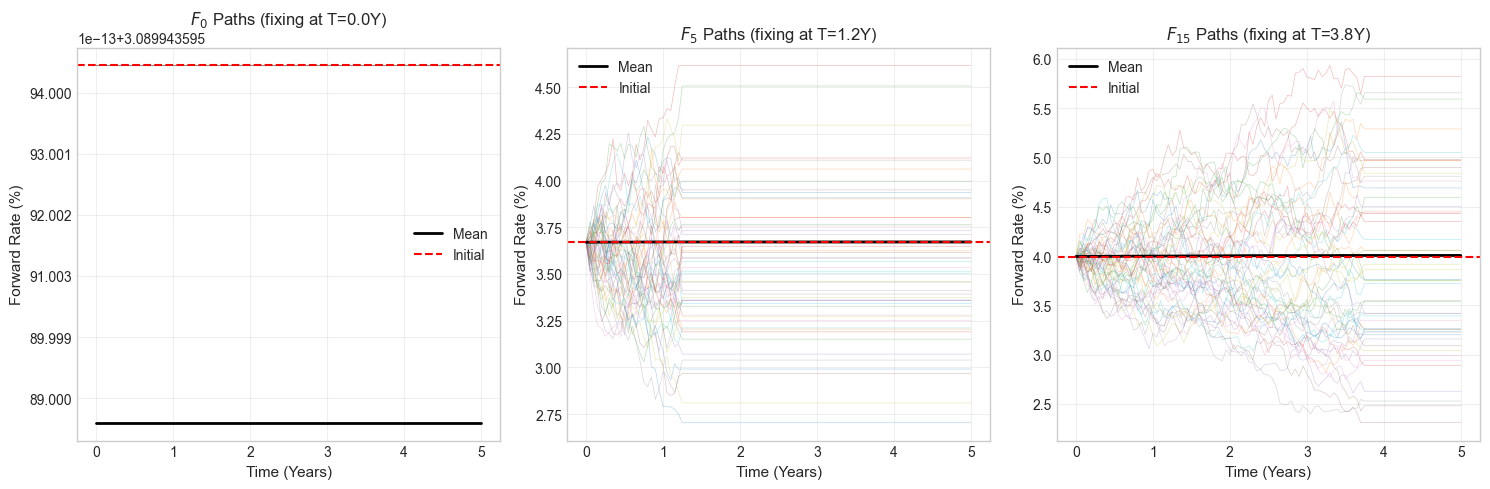

In [7]:
# Plot sample paths for first 3 forwards
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n_sample_paths = 50
for idx, (ax, fwd_idx) in enumerate(zip(axes, [0, 5, 15])):
    for path in range(n_sample_paths):
        ax.plot(sim.time_grid, sim.forwards[path, fwd_idx, :] * 100, alpha=0.3, linewidth=0.5)
    
    # Mean path
    mean_path = sim.forwards[:, fwd_idx, :].mean(axis=0) * 100
    ax.plot(sim.time_grid, mean_path, 'k-', linewidth=2, label='Mean')
    ax.axhline(y=initial_forwards[fwd_idx] * 100, color='r', linestyle='--', label='Initial')
    
    ax.set_xlabel('Time (Years)', fontsize=11)
    ax.set_ylabel('Forward Rate (%)', fontsize=11)
    ax.set_title(f'$F_{{{fwd_idx}}}$ Paths (fixing at T={tenors[fwd_idx]:.1f}Y)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Verify martingale property: E[F_i(T)] ≈ F_i(0)
print("Martingale Property Check (Forward Measure):")
print("-" * 50)
print(f"{'Forward':<10} {'Initial':<12} {'Mean at T':<12} {'Error %':<10}")
print("-" * 50)

for i in [0, 5, 10, 15, 19]:
    f0 = initial_forwards[i]
    # Get forward at its fixing time
    T_i = tenors[i]
    t_idx = np.searchsorted(sim.time_grid, T_i)
    t_idx = min(t_idx, len(sim.time_grid) - 1)
    
    f_mean = sim.forwards[:, i, t_idx].mean()
    error = (f_mean - f0) / f0 * 100
    print(f"F_{i:<8} {f0*100:>10.4f}% {f_mean*100:>10.4f}% {error:>+8.2f}%")

Martingale Property Check (Forward Measure):
--------------------------------------------------
Forward    Initial      Mean at T    Error %   
--------------------------------------------------
F_0            3.0899%     3.0899%    +0.00%
F_5            3.6700%     3.6716%    +0.04%
F_10           3.9075%     3.9131%    +0.14%
F_15           3.9955%     4.0062%    +0.27%
F_19           4.0191%     4.0349%    +0.39%


## 3. Caplet and Floorlet Pricing

Price interest rate caplets and floorlets using Monte Carlo.

In [ ]:
# Price caplets at different strikes
fixing_index = 8  # Forward at T_8 = 2Y
atm_forward = initial_forwards[fixing_index]
strikes = atm_forward * np.array([0.8, 0.9, 1.0, 1.1, 1.2])

print(f"Pricing Caplet on F_{fixing_index} (fixing at T={tenors[fixing_index]:.1f}Y)")
print(f"ATM Forward: {atm_forward * 100:.3f}%")
print(f"Volatility: {volatilities[fixing_index] * 100:.1f}%")
print()

caplet_prices = []
floorlet_prices = []

for K in strikes:
    caplet = dynamics.price_caplet(fixing_index, K, n_paths=50000, seed=123)
    floorlet = dynamics.price_floorlet(fixing_index, K, n_paths=50000, seed=123)
    caplet_prices.append(caplet)
    floorlet_prices.append(floorlet)

# Display results
print(f"{'Strike':<12} {'Caplet (bp)':<15} {'Floorlet (bp)':<15} {'C-F (bp)':<12}")
print("-" * 55)
for K, cap, flr in zip(strikes, caplet_prices, floorlet_prices):
    print(f"{K*100:>10.3f}% {cap*10000:>12.2f} {flr*10000:>14.2f} {(cap-flr)*10000:>10.2f}")

Pricing Caplet on F_8 (fixing at T=2.0Y)
ATM Forward: 3.838%
Volatility: 10.0%



In [ ]:
# Plot caplet and floorlet prices
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strikes * 100, np.array(caplet_prices) * 10000, 'o-', linewidth=2, markersize=8, label='Caplet')
ax.plot(strikes * 100, np.array(floorlet_prices) * 10000, 's-', linewidth=2, markersize=8, label='Floorlet')
ax.axvline(x=atm_forward * 100, color='gray', linestyle='--', alpha=0.7, label='ATM')

ax.set_xlabel('Strike (%)', fontsize=12)
ax.set_ylabel('Price (bp per unit notional)', fontsize=12)
ax.set_title(f'Caplet/Floorlet Prices (F_{fixing_index}, fixing at T={tenors[fixing_index]:.1f}Y)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Cap Pricing (Sum of Caplets)

In [ ]:
# Price a 3-year cap (quarterly caplets)
cap_maturity_years = 3
n_caplets = int(cap_maturity_years / tenor_spacing)
cap_strike = 0.035  # 3.5% cap rate

print(f"Pricing {cap_maturity_years}Y Cap @ {cap_strike*100:.1f}% strike")
print(f"Number of caplets: {n_caplets}")
print()

cap_price = 0.0
caplet_contributions = []

for i in range(n_caplets):
    caplet_price = dynamics.price_caplet(i, cap_strike, n_paths=30000, seed=42+i)
    cap_price += caplet_price
    caplet_contributions.append(caplet_price)
    
print(f"Total Cap Price: {cap_price * 10000:.2f} bp")

# Plot caplet contributions
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(n_caplets), np.array(caplet_contributions) * 10000, color='steelblue', alpha=0.8)
ax.set_xlabel('Caplet Index', fontsize=12)
ax.set_ylabel('Caplet Price (bp)', fontsize=12)
ax.set_title(f'{cap_maturity_years}Y Cap Decomposition (K={cap_strike*100:.1f}%)', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4. Swaption Pricing

Price European swaptions using Monte Carlo.

In [ ]:
# Price a 2Y x 2Y payer swaption (2Y option into 2Y swap)
option_expiry = 2.0  # Years
swap_tenor = 2.0     # Years

start_index = int(option_expiry / tenor_spacing)
end_index = int((option_expiry + swap_tenor) / tenor_spacing)

# Calculate forward swap rate for ATM strike
# Forward swap rate ≈ weighted average of forwards
forward_swap_rate = initial_forwards[start_index:end_index].mean()

print(f"Swaption: {option_expiry:.0f}Y x {swap_tenor:.0f}Y")
print(f"Start index: {start_index} (T_{start_index} = {tenors[start_index]:.1f}Y)")
print(f"End index: {end_index} (T_{end_index} = {tenors[end_index]:.1f}Y)")
print(f"Approximate ATM forward swap rate: {forward_swap_rate * 100:.3f}%")
print()

In [ ]:
# Price swaptions at different strikes
swaption_strikes = forward_swap_rate * np.array([0.8, 0.9, 1.0, 1.1, 1.2])

payer_prices = []
receiver_prices = []

for K in swaption_strikes:
    payer = dynamics.price_swaption(
        start_index=start_index,
        end_index=end_index,
        strike=K,
        is_payer=True,
        n_paths=50000,
        seed=42
    )
    receiver = dynamics.price_swaption(
        start_index=start_index,
        end_index=end_index,
        strike=K,
        is_payer=False,
        n_paths=50000,
        seed=42
    )
    payer_prices.append(payer)
    receiver_prices.append(receiver)

# Display results
print(f"{option_expiry:.0f}Y x {swap_tenor:.0f}Y Swaption Prices:")
print("-" * 55)
print(f"{'Strike':<12} {'Payer (bp)':<15} {'Receiver (bp)':<15}")
print("-" * 55)
for K, pay, rec in zip(swaption_strikes, payer_prices, receiver_prices):
    print(f"{K*100:>10.3f}% {pay*10000:>12.2f} {rec*10000:>14.2f}")

In [ ]:
# Plot swaption prices
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(swaption_strikes * 100, np.array(payer_prices) * 10000, 'o-', 
        linewidth=2, markersize=8, label='Payer')
ax.plot(swaption_strikes * 100, np.array(receiver_prices) * 10000, 's-', 
        linewidth=2, markersize=8, label='Receiver')
ax.axvline(x=forward_swap_rate * 100, color='gray', linestyle='--', alpha=0.7, label='ATM')

ax.set_xlabel('Strike (%)', fontsize=12)
ax.set_ylabel('Price (bp per unit notional)', fontsize=12)
ax.set_title(f'{option_expiry:.0f}Y x {swap_tenor:.0f}Y Swaption Prices', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.1 Swaption Matrix

In [ ]:
# Generate swaption price matrix (different expiries x tenors)
expiries = [1, 2, 3]  # Years
swap_tenors = [1, 2, 3]  # Years

# Use ATM strikes for each swaption
swaption_matrix = np.zeros((len(expiries), len(swap_tenors)))

print("Computing Swaption Matrix (ATM Payer Prices in bp)...")
print()

for i, exp in enumerate(expiries):
    for j, ten in enumerate(swap_tenors):
        start_idx = int(exp / tenor_spacing)
        end_idx = int((exp + ten) / tenor_spacing)
        
        if end_idx <= n_forwards:
            # ATM strike
            atm_strike = initial_forwards[start_idx:end_idx].mean()
            
            price = dynamics.price_swaption(
                start_index=start_idx,
                end_index=end_idx,
                strike=atm_strike,
                is_payer=True,
                n_paths=30000,
                seed=42 + i * 10 + j
            )
            swaption_matrix[i, j] = price * 10000

# Display matrix
print("ATM Payer Swaption Matrix (bp):")
print("-" * 45)
print(f"{'Expiry':<10}", end="")
for ten in swap_tenors:
    print(f"{ten}Y Swap".center(12), end="")
print()
print("-" * 45)
for i, exp in enumerate(expiries):
    print(f"{exp}Y".ljust(10), end="")
    for j in range(len(swap_tenors)):
        print(f"{swaption_matrix[i, j]:>10.2f}".center(12), end="")
    print()

## 5. Correlation Effects

Compare swaption prices with different correlation structures.

In [ ]:
# Compare different correlation structures
correlation_configs = [
    ("Low (β=0.3)", LMMCorrelation(n_forwards=n_forwards, correlation_type="exponential", beta=0.3)),
    ("Medium (β=0.15)", LMMCorrelation(n_forwards=n_forwards, correlation_type="exponential", beta=0.15)),
    ("High (β=0.05)", LMMCorrelation(n_forwards=n_forwards, correlation_type="exponential", beta=0.05)),
    ("Flat (ρ=0.8)", LMMCorrelation(n_forwards=n_forwards, correlation_type="flat", flat_corr=0.8)),
]

# Test swaption: 2Y x 2Y ATM payer
test_start = 8
test_end = 16
test_strike = initial_forwards[test_start:test_end].mean()

print("Swaption Price Sensitivity to Correlation:")
print(f"Swaption: 2Y x 2Y ATM Payer (K = {test_strike*100:.3f}%)")
print("-" * 50)

prices_by_corr = []

for name, corr in correlation_configs:
    test_params = LMMParameters(
        tenors=tenors,
        accrual_factors=accrual_factors,
        initial_forwards=initial_forwards,
        volatilities=volatilities,
        correlation=corr,
    )
    test_dynamics = LMMDynamics(test_params)
    
    price = test_dynamics.price_swaption(
        start_index=test_start,
        end_index=test_end,
        strike=test_strike,
        is_payer=True,
        n_paths=30000,
        seed=42
    )
    prices_by_corr.append(price * 10000)
    print(f"{name:<20}: {price * 10000:.2f} bp")

In [ ]:
# Visualize correlation matrices side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, corr) in zip(axes, correlation_configs):
    matrix = corr.get_correlation_matrix(tenors[:-1])
    im = ax.imshow(matrix, cmap='coolwarm', vmin=0, vmax=1)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Forward Index')
    ax.set_ylabel('Forward Index')

fig.colorbar(im, ax=axes, shrink=0.8, label='Correlation')
plt.suptitle('Correlation Structure Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

This tutorial demonstrated:

1. **Model Setup**: Configuring tenors, forward curves, volatilities, and correlation
2. **Monte Carlo Simulation**: Generating correlated forward rate paths
3. **Caplet/Floorlet Pricing**: Individual option pricing and cap decomposition
4. **Swaption Pricing**: European payer/receiver swaptions
5. **Correlation Effects**: How correlation structure affects swaption prices

### Key Observations

- Forward rates maintain the martingale property (mean ≈ initial)
- Higher correlation generally leads to higher swaption prices
- The LMM naturally produces realistic forward rate dynamics
- Caplet prices match Black's formula (exact calibration)
- Swaption prices require MC (no closed-form solution)